In [31]:
import os
import cv2 as cv
import numpy as np
from imutils import rotate
from skimage.io import imshow

from inspection.support.utils import align, extract, cut
from settings import OPEN_AOI_DATASET_PATH

# Setup


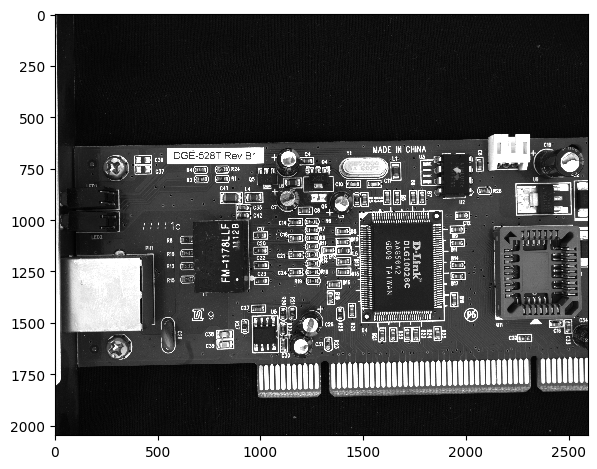

In [100]:
target_folders = [
    "21_netcard_um_16mm_f8_4320",
    "22_netcard_um_16mm_f8_3101",
    "23_netcard_um_16mm_f8_5014",
]

# Image to perform inspection against
template = cv.cvtColor(
    cv.imread("inspection/support/capacitor_orientation/originals/netcard.bmp"),
    cv.COLOR_BGR2GRAY,
)
# Image with mask to remove capacitor impurities from sample image
mask_fix = cv.cvtColor(
    cv.imread("inspection/support/capacitor_orientation/masks/netcard_fix.png"),
    cv.COLOR_BGR2GRAY,
)
# Image with control zones masks
mask_inspection_zone_color = np.array([255, 0, 0])
mask_inspection_zones = cv.cvtColor(
    cv.imread(
        "inspection/support/capacitor_orientation/masks/netcard_inspection_zones.png"
    ),
    cv.COLOR_BGR2RGB,
)
imshow(template)

# Mask transfer and control area selection

Select all masked components for accuracy tests. Store components them self (chunks), coordinates in tested image and label of chunk.


In [105]:
all_images = []  # [im1, im2, ...]
all_stats = []  # [[val1, val2, ...], ...]

for folder in target_folders:
    print(f"Processing: {folder}")
    for file in os.listdir(f"{OPEN_AOI_DATASET_PATH}/{folder}"):

        # Load each image to perform inspection on
        test_image = cv.cvtColor(
            cv.imread(f"{OPEN_AOI_DATASET_PATH}/{folder}/{file}"), cv.COLOR_RGB2GRAY
        )

        # Align image with template
        test_image = align(test_image, template)
        all_images.append(test_image)

        # Create the overlay
        test_image = cv.addWeighted(test_image, 1, mask_fix, 1, 0)

        # Extract with mask
        _, stats = extract(test_image, mask_inspection_zone_color, mask_inspection_zones)
        all_stats.append(stats)

    #     imshow(test_image)
    #     break
    # break

print(
    f"Total images: {len(all_images)}, total chunks: {len(all_images) * len(all_stats[0])} (x2 total test cases)"
)

Processing: 21_netcard_um_16mm_f8_4320
Processing: 22_netcard_um_16mm_f8_3101
Processing: 23_netcard_um_16mm_f8_5014
Total images: 29, total chunks: 58 (x2 total test cases)


# Orientation inspection


In [96]:
def is_orientation_correct(
    template_chunk: np.ndarray,
    test_chunk: np.ndarray,
    binary_thresh: int,
    kernel_size: int,
    erosion_iter: int,
):
    # Calculate difference
    difference = cv.absdiff(template_chunk, test_chunk)

    # Binary image
    _, im = cv.threshold(difference, binary_thresh, 255, cv.THRESH_BINARY)

    # Erode binary image so only orientation marker blobs are left
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    im = cv.erode(im, kernel, iterations=erosion_iter)

    # Apply the Component analysis function
    (total_labels, _, _, _) = cv.connectedComponentsWithStats(im, 4, cv.CV_32S)

    # If orientation matches, expect at most 1 component
    # else there will be 2 components
    return total_labels - 1 <= 1

### Test case generation


Is orientation correct: False


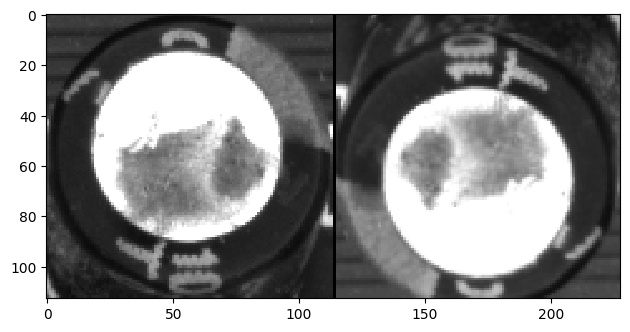

In [104]:
image_index = 28
stats_index = 0

test_image = all_images[image_index]
test_stats = all_stats[image_index][stats_index]

template_chunk = cut(template, test_stats)
test_chunk = rotate(cut(test_image, test_stats), 180)

imshow(np.hstack([template_chunk, test_chunk]))
print(
    f"Is orientation correct: {is_orientation_correct(template_chunk, test_chunk, 50, 3, 5)}"
)

## Grid search

Apply grid search to find best parameters for the algorithm. Related accuracy is best achievable accuracy in this case. 

In [121]:
best_binary_thresh = 50
best_kernel_size = 3
best_erosion_iter = 2

best_acc = 0

for binary_thresh in range(30, 100):
    for kernel_size in range(2, 7):
        for erosion_iter in range(2, 5):

            # Positive = rotated
            tp = 0  # true positive (rotated)
            fp = 0  # false positive

            tn = 0  # true negative (not rotated)
            fn = 0  # false negative

            for test_image, all_test_stats in zip(all_images, all_stats):
                for test_stats in all_test_stats:
                    template_chunk = cut(template, test_stats)

                    test_chunk = cut(test_image, test_stats)
                    test_chunk_rotated = rotate(test_chunk, 180)

                    result = is_orientation_correct(
                        template_chunk,
                        test_chunk,
                        binary_thresh,
                        kernel_size,
                        erosion_iter,
                    )
                    if result:
                        tn += 1
                    else:
                        fp += 1

                    result_rotated = is_orientation_correct(
                        template_chunk,
                        test_chunk_rotated,
                        binary_thresh,
                        kernel_size,
                        erosion_iter,
                    )
                    if result_rotated:
                        fn += 1
                    else:
                        tp += 1

            acc = (tp + tn) / sum([tp, tn, fp, fn])
            if acc > best_acc:
                best_acc = acc

                best_binary_thresh = binary_thresh
                best_kernel_size = kernel_size
                best_erosion_iter = erosion_iter

print(f"Best achievable accuracy: {best_acc:.3%}")
print("Parameters: ", best_binary_thresh, best_kernel_size, best_erosion_iter)

Best achievable accuracy: 98.276%
Parameters:  34 4 4
